## Coursera - ML 
### Lab Walkthrough: Building a Regression Model

##### 1. Pull data from yfinance into a Pandas dataframe
##### 2. Use Matplotlib to visualize data
##### 3. Use Scikit-learn to build a regression model

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## 1. Pull Data from Yfinance

In [21]:
df = yf.download('AAPL', start='2010-01-01', end='2020-01-01')
df = df[['Close']].copy()
df.columns = ['Close']
df.index.name = 'Date'

# # LAG fetaures
# df['min_1_Close'] = df['Close'].shift(1)
# df['min_2_Close'] = df['Close'].shift(2)
# df['min_3_Close'] = df['Close'].shift(3)
# df['min_4_Close'] = df['Close'].shift(4)

# #Trend features
# df['min_1_Close'] = np.where(df['min_1_Close'] - df['min_2_Close'] > 0, 1, -1)
# df['min_2_Close'] = np.where(df['min_2_Close'] - df['min_3_Close'] > 0, 1, -1)
# df['min_3_Close'] = np.where(df['min_3_Close'] - df['min_4_Close'] > 0, 1, -1)

#day_prev_close = yesterday's close
df['day_prev_close'] = df['Close'].shift(1)

#trend_3_day = was price higher 1 day ago vs 3 dyas ago?
df['trend_3_day'] = np.where(df['Close'] - df['Close'].shift(3) > 0, 1, -1)

df.reset_index(inplace=True)
df.dropna(inplace=True)f
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,day_prev_close,trend_3_day
1,2010-01-05,6.417556,6.406480,-1
2,2010-01-06,6.315478,6.417556,-1
3,2010-01-07,6.303802,6.315478,-1
4,2010-01-08,6.345713,6.303802,-1
5,2010-01-11,6.289733,6.345713,-1


## 2. Visualize data

<Axes: xlabel='Date'>

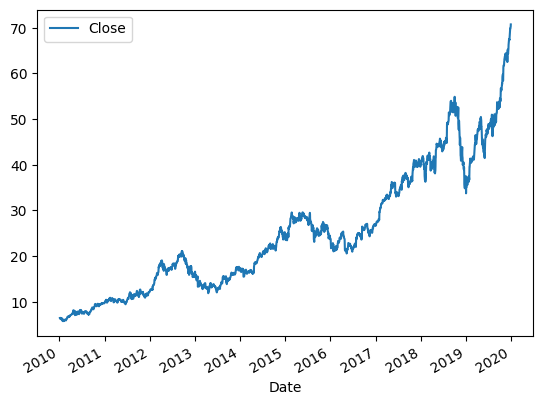

In [27]:
df.plot(x='Date', y='Close')

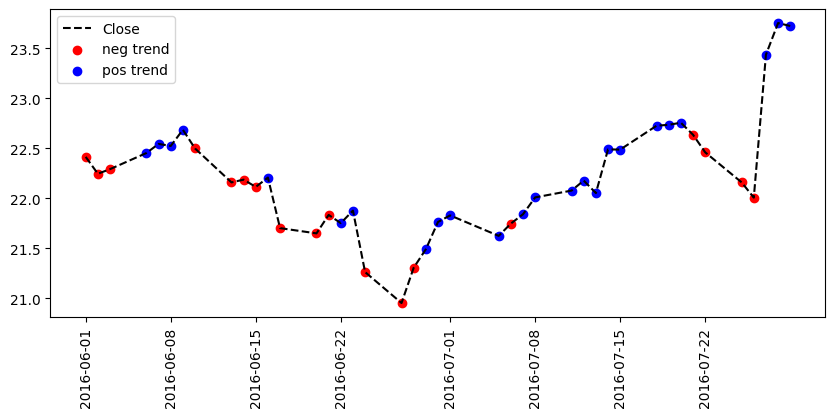

In [60]:
start_date = '2016-06-01'
end_date = '2016-07-31'
mask = pd.to_datetime(df.Date).between(start_date, end_date)

plt.figure(figsize=(10,4))

plt.plot('Date', 'Close', 'k--',
        data = (
            df.loc[mask]
        )
        )

plt.scatter('Date', 'Close', color='r', label='neg trend',
            data = (
                df.loc[(df.trend_3_day == -1) & mask]
            )
           )

plt.scatter('Date', 'Close', color='b', label='pos trend',
            data = (
                df.loc[(df.trend_3_day == 1) & mask]
            )
           )

plt.legend()
plt.xticks(rotation = 90);

In [61]:
df.shape

(2515, 4)

## 3. Build a Regression Model in Scikit-Learn

In [81]:
features = ['day_prev_close', 'trend_3_day']  # inputs (X)
target = 'Close'  # what we're predicting (y)

X_train, X_test = df.loc[:2000, features], df.loc[2000:, features]  # first 2000 rows to learn from & remaining rows to test on
y_train, y_test = df.loc[:2000, target], df.loc[2000:, target]  # first 2000 actual prices & remaining actual prices

In [77]:
# Create linear regression object
regr = linear_model.LinearRegression(fit_intercept=False)

In [78]:
# Train the model using the training set
regr.fit(X_train, y_train)  # model learns the pattern

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
# Make predictions using the training set
y_pred = regr.predict(X_test)  # model guesses prices

In [80]:
# Evaluate
# How wrong are predictions on average? - the mean squared error
print(f'The Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')

# Explained Variance score - 1 is perfect & 0 is terrible
print(f'Variance Score: {r2_score(y_test,y_pred):.2f}')

The Root Mean Squared Error: 0.73
Variance Score: 0.99


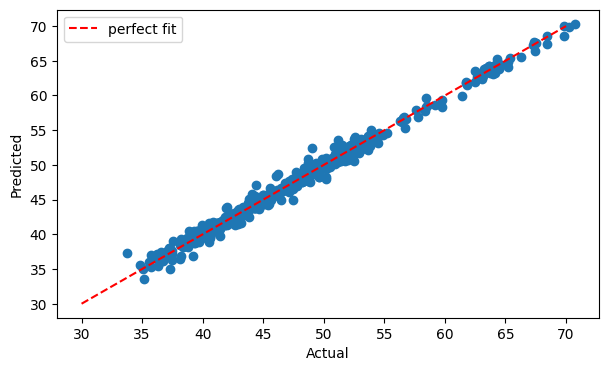

In [91]:
# Plot actual vs Predicted
plt.figure(figsize=(7,4))

plt.scatter(y_test, y_pred)
plt.plot([30,70], [30,70], 'r--', label='perfect fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend();

In [100]:
# Naive baseline - just use yesterday's price as prediction
print(f'The Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, X_test['day_prev_close'])):.2f}')

The Root Mean Squared Error: 0.78


In [109]:
# ML Model vs Naive Baseline
model_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
naive_rmse = np.sqrt(mean_squared_error(y_test, X_test['day_prev_close']))

if model_rmse < naive_rmse:
   print('My Linear Regression ML Model won!')
else:
   print('My Linear Regression ML Model failed!')

My Linear Regression ML Model won!
